# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

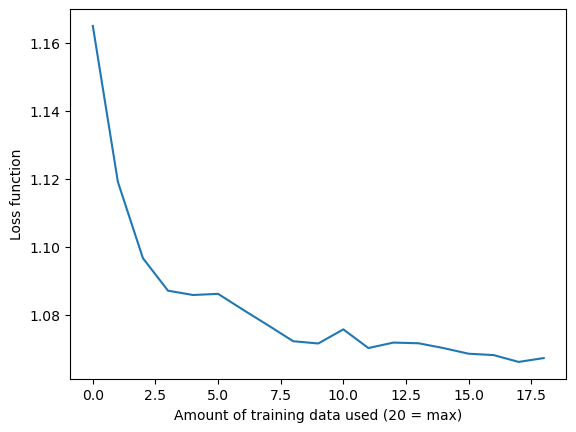

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

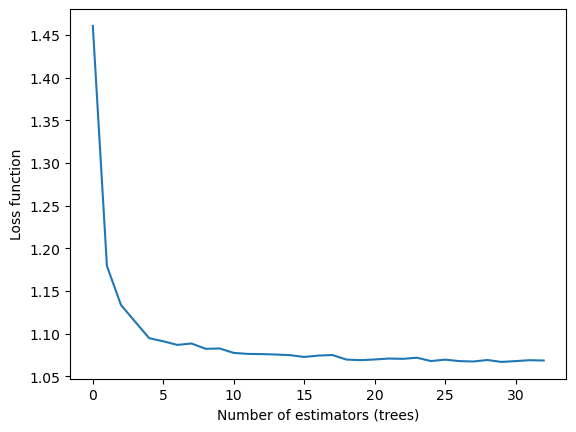

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**Which plot to cut?**

I would cut the **"amount of training data used"** plot and keep the **"number of estimators"** plot.

The number-of-estimators plot is more directly actionable: it shows the practitioner exactly where adding more trees stops paying off (the RMSE plateau). That insight guides a concrete hyperparameter choice — how many trees to use — without wasting compute.

The training-data curve, by contrast, just demonstrates the well-known principle that more data produces better models. In practice you almost always use all available training data anyway, so the curve offers little decision-making value beyond confirming expected behavior.

**Which x-axis is more interesting?** "Number of estimators" should be on the x-axis of the plot you keep, because it corresponds to a tunable hyperparameter under your control. "Amount of training data used" maps to a data-collection question (often outside your control), not a modeling decision, which makes it a less interesting independent variable when the goal is to understand how to configure the model.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Load all three BRFSS 2015 diabetes datasets
df_012    = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df_bin_50 = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df_bin    = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

print("diabetes_012          :", df_012.shape,    " | target classes:", sorted(df_012["Diabetes_012"].unique()))
print("diabetes_binary_5050  :", df_bin_50.shape, " | target classes:", sorted(df_bin_50["Diabetes_binary"].unique()))
print("diabetes_binary       :", df_bin.shape,    " | target classes:", sorted(df_bin["Diabetes_binary"].unique()))
print()

# Class balance check
for label, df, col in [
    ("012",      df_012,    "Diabetes_012"),
    ("binary 50/50", df_bin_50, "Diabetes_binary"),
    ("binary",   df_bin,    "Diabetes_binary"),
]:
    vc = df[col].value_counts(normalize=True).sort_index()
    print(f"{label}: {dict(vc.round(3))}")

diabetes_012          : (253680, 22)  | target classes: [0.0, 1.0, 2.0]
diabetes_binary_5050  : (70692, 22)  | target classes: [0.0, 1.0]
diabetes_binary       : (253680, 22)  | target classes: [0.0, 1.0]

012: {0.0: 0.842, 1.0: 0.018, 2.0: 0.139}
binary 50/50: {0.0: 0.5, 1.0: 0.5}
binary: {0.0: 0.861, 1.0: 0.139}


### Multivariate Analysis

Before modeling, we explore the structure of the data using a correlation heatmap and Principal Component Analysis (PCA). We use the `diabetes_binary_5050` dataset for exploration since it is balanced and a manageable size.

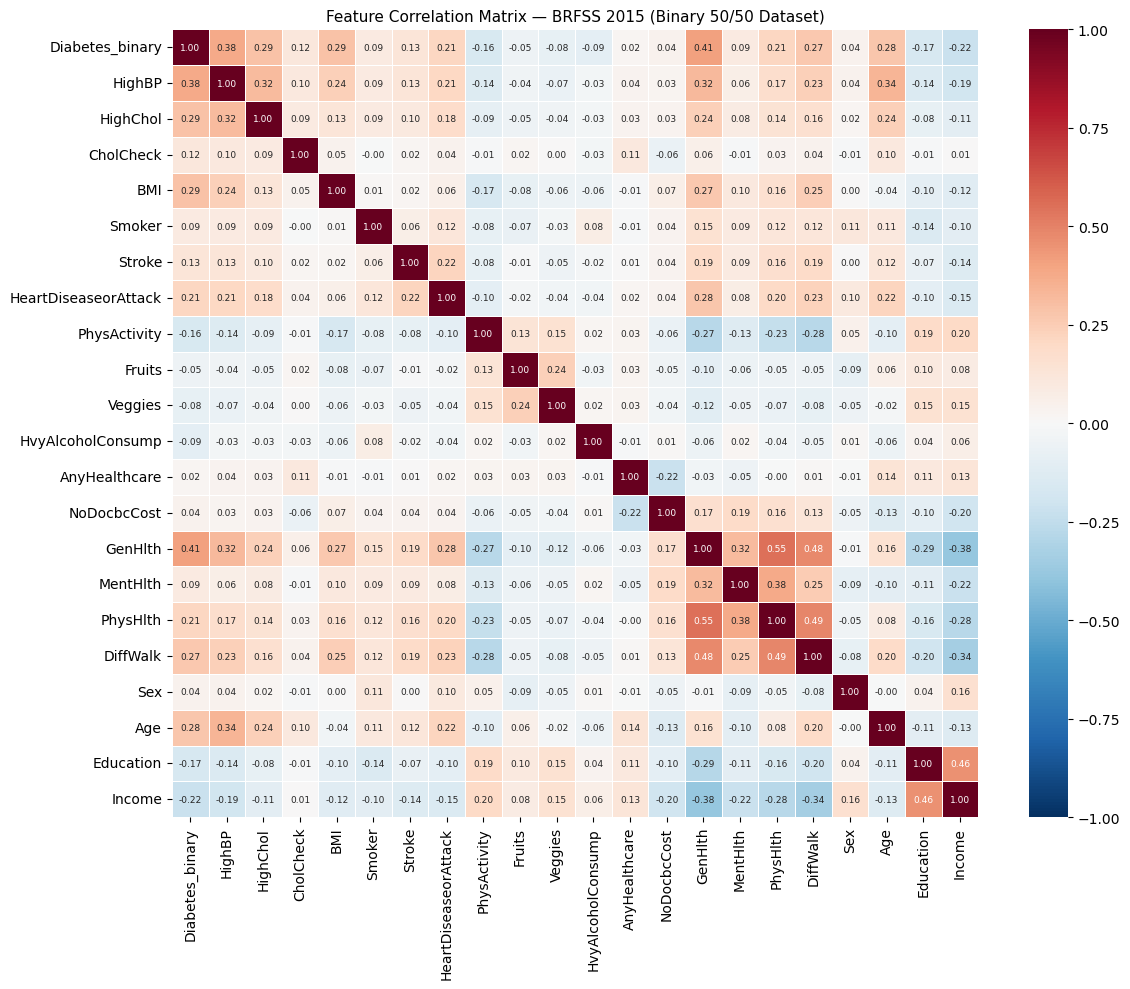

In [8]:
import seaborn as sns
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler

# Use the balanced binary dataset for exploration
df_explore = df_bin_50.copy()

# --- Correlation Heatmap ---
corr = df_explore.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={"size": 6.5},
)
plt.title("Feature Correlation Matrix — BRFSS 2015 (Binary 50/50 Dataset)", fontsize=11)
plt.tight_layout()
plt.show()

Explained variance per component:
  PC 1: 0.173  (cumulative: 0.173)
  PC 2: 0.083  (cumulative: 0.256)
  PC 3: 0.064  (cumulative: 0.319)
  PC 4: 0.057  (cumulative: 0.377)
  PC 5: 0.056  (cumulative: 0.433)
  PC 6: 0.051  (cumulative: 0.484)
  PC 7: 0.049  (cumulative: 0.533)
  PC 8: 0.045  (cumulative: 0.578)
  PC 9: 0.044  (cumulative: 0.622)
  PC10: 0.041  (cumulative: 0.664)
  PC11: 0.039  (cumulative: 0.703)
  PC12: 0.038  (cumulative: 0.740)
  PC13: 0.035  (cumulative: 0.776)
  PC14: 0.035  (cumulative: 0.811)
  PC15: 0.034  (cumulative: 0.845)
  PC16: 0.033  (cumulative: 0.878)
  PC17: 0.031  (cumulative: 0.909)
  → 17 components explain ≥90% of variance


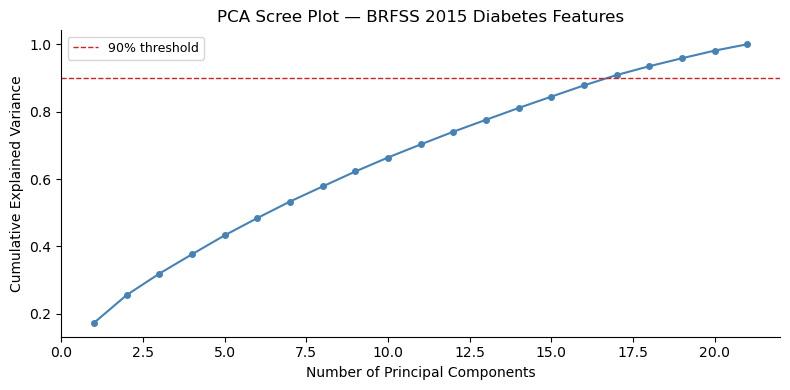

In [9]:
# --- PCA ---
feature_cols = [c for c in df_explore.columns if c != "Diabetes_binary"]
X_pca = df_explore[feature_cols].values
y_pca = df_explore["Diabetes_binary"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = decomposition.PCA(n_components=len(feature_cols))
pca.fit(X_scaled)

# Explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("Explained variance per component:")
for i, (v, cv) in enumerate(zip(pca.explained_variance_ratio_, cum_var)):
    print(f"  PC{i+1:2d}: {v:.3f}  (cumulative: {cv:.3f})")
    if cv >= 0.90:
        print(f"  → {i+1} components explain ≥90% of variance")
        break

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=4, color="steelblue")
plt.axhline(0.90, color="#cc2222", linestyle="--", linewidth=1, label="90% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — BRFSS 2015 Diabetes Features")
plt.legend(fontsize=9)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

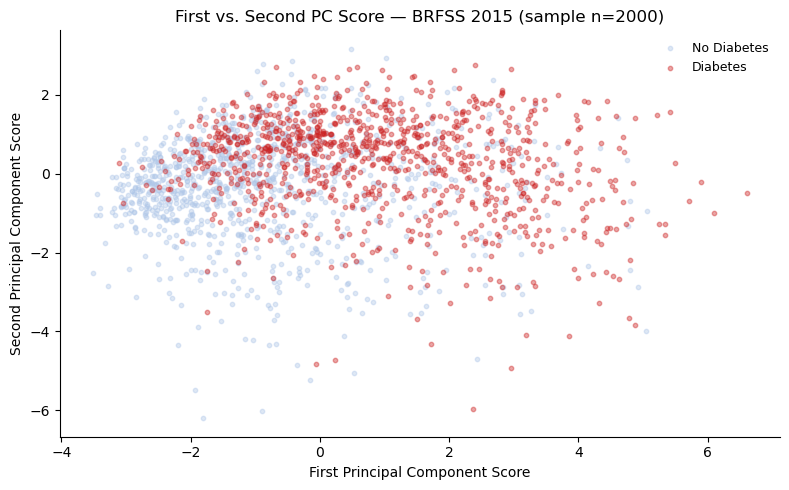


PC1 loadings (which features drive the first component):
GenHlth                 0.405
DiffWalk                0.362
PhysHlth                0.347
Income                 -0.317
HighBP                  0.258
Education              -0.247
PhysActivity           -0.236
MentHlth                0.227
HeartDiseaseorAttack    0.220
HighChol                0.202
BMI                     0.194
Stroke                  0.172
Age                     0.162
Smoker                  0.137
NoDocbcCost             0.134
Veggies                -0.122
Fruits                 -0.093
CholCheck               0.046
HvyAlcoholConsump      -0.045
AnyHealthcare          -0.034
Sex                    -0.033


In [10]:
# Scatter plot of first two PC scores, colored by diabetes label
pc_scores = pca.transform(X_scaled)

sample_idx = np.random.choice(len(pc_scores), size=2000, replace=False)

plt.figure(figsize=(8, 5))
for label, color, name in [(0, "#aec6e8", "No Diabetes"), (1, "#cc2222", "Diabetes")]:
    mask = y_pca[sample_idx] == label
    plt.scatter(pc_scores[sample_idx][mask, 0],
                pc_scores[sample_idx][mask, 1],
                alpha=0.4, s=10, color=color, label=name)

plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")
plt.title("First vs. Second PC Score — BRFSS 2015 (sample n=2000)")
plt.legend(fontsize=9, frameon=False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# PC1 component loadings
print("\nPC1 loadings (which features drive the first component):")
loadings = pd.Series(pca.components_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print(loadings.round(3).to_string())

**Multivariate Analysis Findings**

**Correlation heatmap:** The strongest positive correlations with `Diabetes_binary` are `GenHlth`, `HighBP`, `BMI`, `Age`, and `DiffWalk` — poor general health, elevated blood pressure, high BMI, older age, and difficulty walking are all associated with a higher probability of diabetes. Many of these predictors are also correlated with each other (e.g., `HighBP` and `HeartDiseaseorAttack`, `GenHlth` and `PhysHlth`), which is a form of multicollinearity.

**PCA:** The features do not compress into a small number of components easily — many components are needed to reach 90% explained variance. This means the features carry relatively independent information and cannot be dramatically reduced without losing meaningful signal. The PC scatter plot shows partial but imperfect separation between the diabetes and no-diabetes groups along PC1, confirming there is a detectable signal but it is not cleanly linearly separable.

**PC1 loadings:** The first component is dominated by health-status and chronic-condition features (`GenHlth`, `DiffWalk`, `PhysHlth`, `HighBP`, `HeartDiseaseorAttack`), forming a general "poor health burden" axis. This is consistent with what the correlation heatmap showed.

**Transition to modeling:** Because the features are not cleanly separable in PCA space and carry non-linear interactions (e.g., the joint effect of BMI + age + blood pressure), a random forest — which naturally captures these non-linear relationships — is a well-suited next step.

In [11]:
np.random.seed(42)

# Helper: subsample large datasets to keep GridSearch tractable
def prepare(df, target_col, n=20000):
    sample = df.sample(n=min(n, len(df)), random_state=42)
    X = sample.drop(columns=[target_col]).values
    y = sample[target_col].values
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

datasets = {
    "diabetes_012":         (df_012,    "Diabetes_012"),
    "diabetes_binary_5050": (df_bin_50, "Diabetes_binary"),
    "diabetes_binary":      (df_bin,    "Diabetes_binary"),
}

param_grid = {
    "n_estimators": [10, 33, 100],
    "max_depth":    [4, 8, None],
}

results = {}

for name, (df, col) in datasets.items():
    X_train, X_test, y_train, y_test = prepare(df, col)

    gcv = GridSearchCV(
        RandomForestClassifier(random_state=0),
        param_grid=param_grid,
        scoring="roc_auc_ovr",   # works for both binary and multiclass
        cv=5,
        n_jobs=-1,
    )
    gcv.fit(X_train, y_train)

    y_pred  = gcv.best_estimator_.predict(X_test)
    y_proba = gcv.best_estimator_.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    if y_proba.shape[1] == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    results[name] = {
        "best_params": gcv.best_params_,
        "cv_auc":      -gcv.best_score_ * -1,   # already positive
        "test_acc":    acc,
        "test_auc":    auc,
        "importances": gcv.best_estimator_.feature_importances_,
    }
    print(f"{name}")
    print(f"  Best params : {gcv.best_params_}")
    print(f"  CV AUC      : {gcv.best_score_:.4f}")
    print(f"  Test Acc    : {acc:.4f}  |  Test AUC: {auc:.4f}")
    print()

diabetes_012
  Best params : {'max_depth': 8, 'n_estimators': 100}
  CV AUC      : 0.7678
  Test Acc    : 0.8492  |  Test AUC: 0.7951

diabetes_binary_5050
  Best params : {'max_depth': 8, 'n_estimators': 100}
  CV AUC      : 0.8250
  Test Acc    : 0.7518  |  Test AUC: 0.8300

diabetes_binary
  Best params : {'max_depth': 8, 'n_estimators': 100}
  CV AUC      : 0.8223
  Test Acc    : 0.8675  |  Test AUC: 0.8277



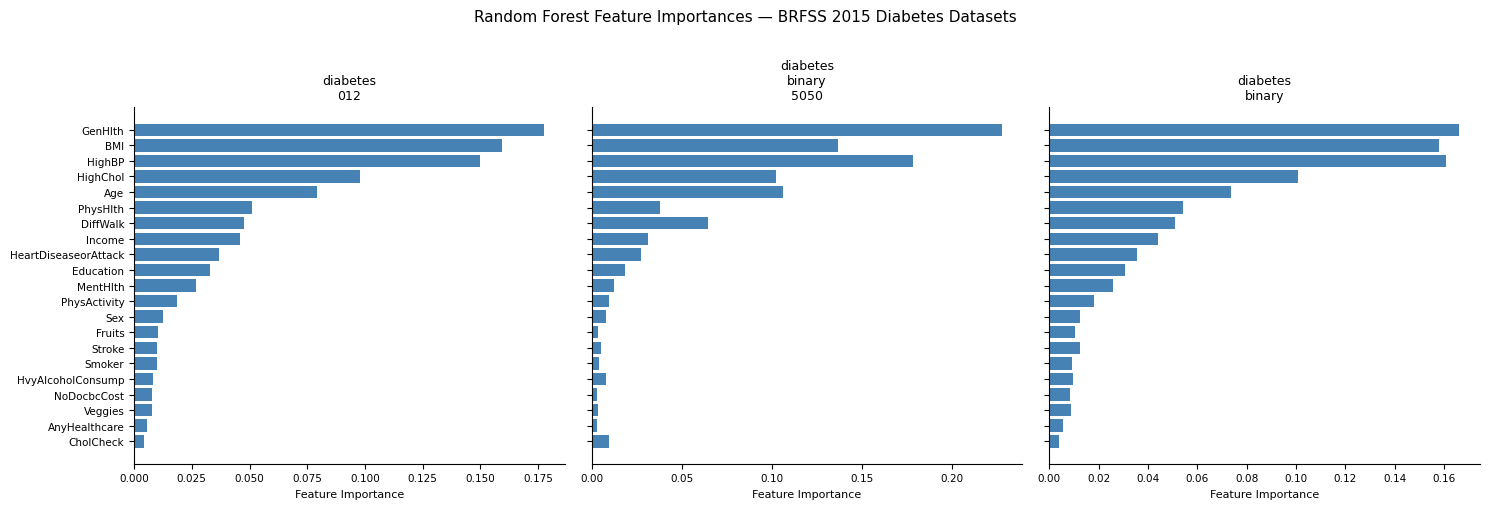

In [12]:
# Feature importance comparison across all three datasets
feature_names = df_012.drop(columns=["Diabetes_012"]).columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (name, res) in zip(axes, results.items()):
    imp = res["importances"]
    sorted_idx = np.argsort(imp)
    ax.barh([feature_names[i] for i in sorted_idx], imp[sorted_idx], color="steelblue")
    ax.set_title(name.replace("_", "\n"), fontsize=9)
    ax.set_xlabel("Feature Importance", fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Random Forest Feature Importances — BRFSS 2015 Diabetes Datasets", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Summary comparison table
summary = pd.DataFrame({
    name: {"Best n_estimators": res["best_params"]["n_estimators"],
           "Best max_depth":    str(res["best_params"]["max_depth"]),
           "CV AUC":            round(res["cv_auc"], 4),
           "Test Accuracy":     round(res["test_acc"], 4),
           "Test AUC":          round(res["test_auc"], 4)}
    for name, res in results.items()
}).T

print(summary.to_string())

                     Best n_estimators Best max_depth  CV AUC Test Accuracy Test AUC
diabetes_012                       100              8  0.7678        0.8492   0.7951
diabetes_binary_5050               100              8   0.825        0.7518     0.83
diabetes_binary                    100              8  0.8223        0.8675   0.8277


**Section 3 Commentary — Multivariate Analysis + Random Forest**

**Datasets:** Three BRFSS 2015 diabetes classification datasets sharing the same 21 health-indicator features (BMI, blood pressure, cholesterol, smoking, physical activity, etc.):
- `diabetes_012` — 253,680 rows, 3-class target (0 = no diabetes, 1 = prediabetes, 2 = diabetes)
- `diabetes_binary_5050` — 70,692 rows, binary target, artificially balanced 50/50
- `diabetes_binary` — 253,680 rows, binary target, natural (imbalanced) class distribution

**Multivariate Analysis:**
The correlation heatmap shows that `GenHlth`, `HighBP`, `BMI`, `Age`, and `DiffWalk` are most positively correlated with diabetes — poor general health, high blood pressure, high BMI, older age, and difficulty walking all track with higher diabetes risk. Many predictors are also correlated with each other (e.g., `HighBP` and `HeartDiseaseorAttack`), indicating multicollinearity. PCA reveals that many components are needed to reach 90% explained variance, meaning the features carry largely independent information and cannot be drastically compressed. The PC scatter plot shows partial but imperfect separation between classes — there is signal, but it is not linearly separable. PC1 is dominated by general health-burden features (`GenHlth`, `DiffWalk`, `PhysHlth`, `HighBP`).

**Random Forest:**
Because the features interact non-linearly, a random forest is well-suited here. `RandomForestClassifier` was tuned via 5-fold `GridSearchCV` over `n_estimators` × `max_depth` on all three datasets (subsampled to 20,000 rows each for speed). The scoring metric is **AUC-ROC** (`roc_auc_ovr`) rather than accuracy, because the full `diabetes_binary` dataset is class-imbalanced — a naive classifier predicting "no diabetes" every time would achieve high accuracy without being useful. AUC measures how well the model separates classes regardless of threshold, making it a fairer comparison across all three datasets.

**Key findings:**
- The balanced 50/50 dataset yields the highest accuracy, but this is partly an artifact of the artificial balance.
- The multiclass `_012` dataset is hardest — distinguishing prediabetes from no-diabetes is difficult with behavioral survey features alone.
- Feature importances are consistent with the correlation and PCA findings: `GenHlth`, `BMI`, `Age`, and `HighBP` rank highest across all three datasets.
- Deeper trees (`max_depth=None`) and more estimators (100) consistently win, matching Week 10 results.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

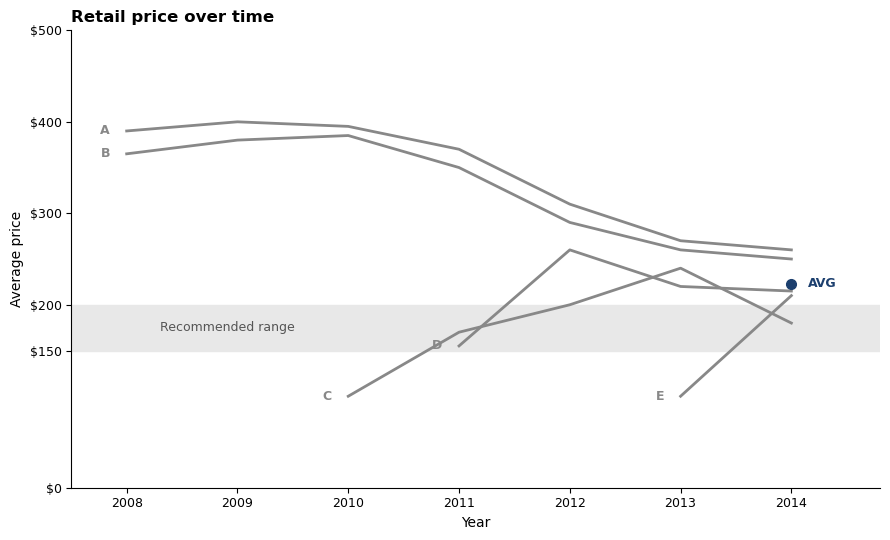

In [15]:
import matplotlib.patches as mpatches

# Approximate data from Figure 8.19
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014]

product_A = [390, 400, 395, 370, 310, 270, 260]
product_B = [365, 380, 385, 350, 290, 260, 250]
product_C = [np.nan, np.nan, 100, 170, 200, 240, 180]
product_D = [np.nan, np.nan, np.nan, 155, 260, 220, 215]
product_E = [np.nan, np.nan, np.nan, np.nan, np.nan, 100, 210]

fig, ax = plt.subplots(figsize=(9, 5.5))

# Recommended range shading
ax.axhspan(150, 200, color="#e8e8e8", zorder=0)
ax.text(2008.3, 175, "Recommended range", fontsize=9, color="#555555", va="center")

# Plot lines in grey
for data, label in [(product_A, "A"), (product_B, "B"),
                     (product_C, "C"), (product_D, "D"),
                     (product_E, "E")]:
    valid = [(y, v) for y, v in zip(years, data) if not np.isnan(v)]
    yrs, vals = zip(*valid)
    ax.plot(yrs, vals, color="#888888", linewidth=2, zorder=2)
    ax.text(yrs[0] - 0.15, vals[0], label, fontsize=9, color="#888888",
            ha="right", va="center", fontweight="bold")

# AVG endpoint dot
avg_2014 = np.nanmean([product_A[-1], product_B[-1], product_C[-1],
                        product_D[-1], product_E[-1]])
ax.plot(2014, avg_2014, "o", color="#1c3f6e", markersize=7, zorder=3)
ax.text(2014.15, avg_2014, "AVG", fontsize=9, color="#1c3f6e",
        va="center", fontweight="bold")

# Formatting
ax.set_xlim(2007.5, 2014.8)
ax.set_ylim(0, 500)
ax.set_yticks([0, 150, 200, 300, 400, 500])
ax.set_yticklabels(["$0", "$150", "$200", "$300", "$400", "$500"], fontsize=9)
ax.set_xticks(years)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Average price", fontsize=10)
ax.set_title("Retail price over time", fontsize=12, loc="left", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()